In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [35]:
import pandas as pd

train_path = "/content/dataset_B_training (1).csv"
test_path = "/content/dataset_B_testing.csv"

# Check if files exist before loading
if os.path.exists(train_path) and os.path.exists(test_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    print("Datasets loaded successfully.")
else:
    print("ERROR: CSV files not found. Please upload the datasets to the /content/ folder.")

Datasets loaded successfully.


In [36]:
print("="*30)
print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE :", test.shape)
print("="*30)

TRAIN SHAPE: (4756, 31)
TEST SHAPE : (4749, 30)


In [37]:
print(f"DATA TYPES")
print(train.dtypes)

print(f"TOTAL MISSING VALUES:", train.isnull().sum().sum())

print(f"DUPLICATE ROWS:", train.duplicated().sum())

print(f"NUMERICAL SUMMARY")
print(train.describe())

print(f"CATEGORICAL SUMMARY")
print(train.describe(include='object'))

DATA TYPES
respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_poverty                  object
marital_status                  object
rent_or_own                     object
employment_sta

In [38]:
print(train.info())

print("\nMissing Values:")
print(train.isnull().sum().sort_values(ascending=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   h1n1_concern                 4741 non-null   float64
 2   h1n1_knowledge               4734 non-null   float64
 3   behavioral_antiviral_meds    4739 non-null   float64
 4   behavioral_avoidance         4729 non-null   float64
 5   behavioral_face_mask         4752 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4741 non-null   float64
 9   behavioral_touch_face        4736 non-null   float64
 10  doctor_recc_h1n1             4437 non-null   float64
 11  chronic_med_condition        4595 non-null   float64
 12  child_under_6_months         4622 non-null   float64
 13  health_worker     

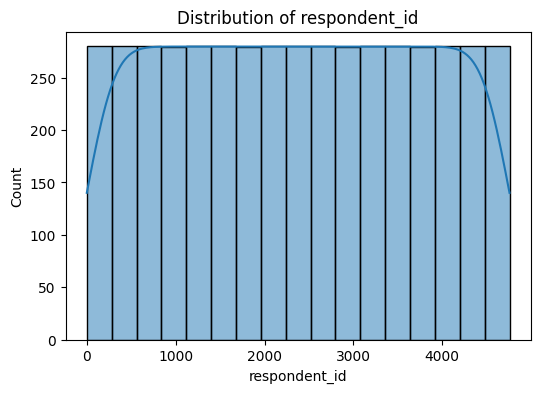

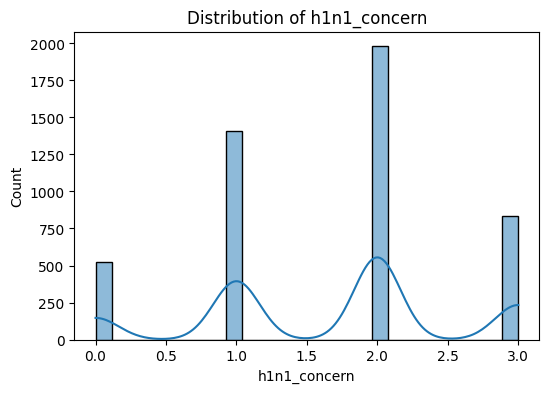

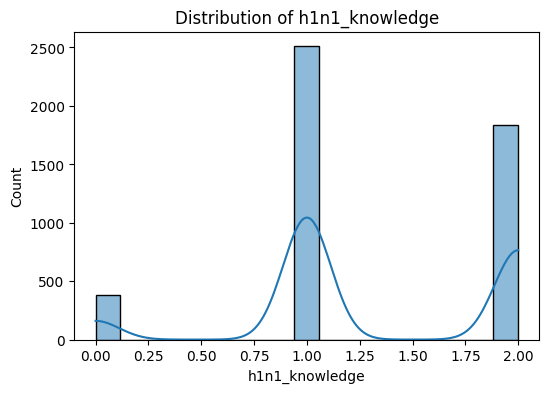

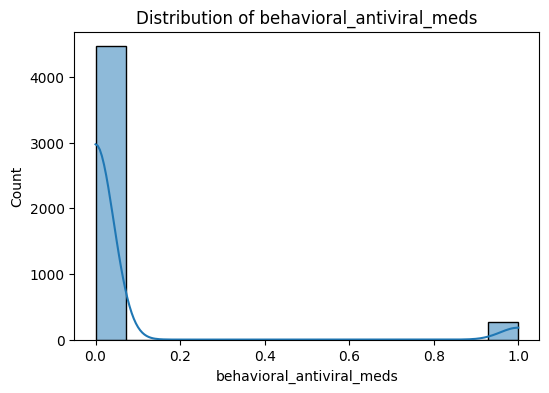

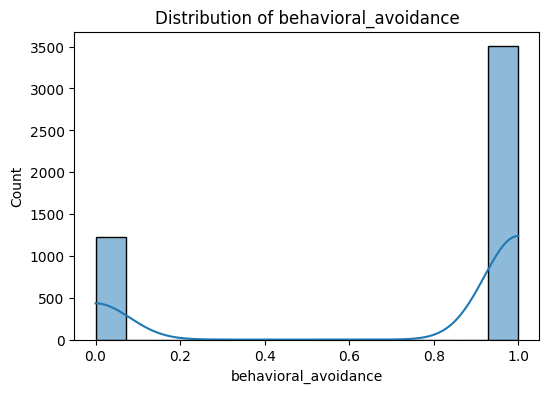

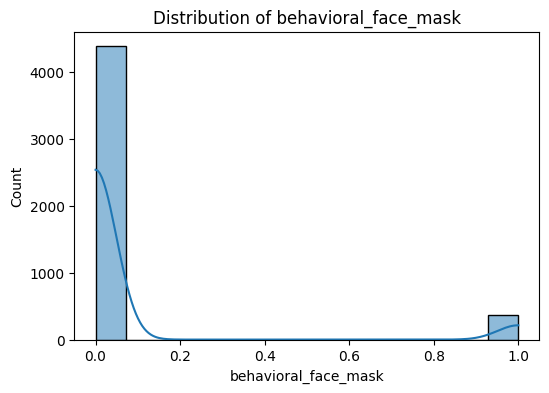

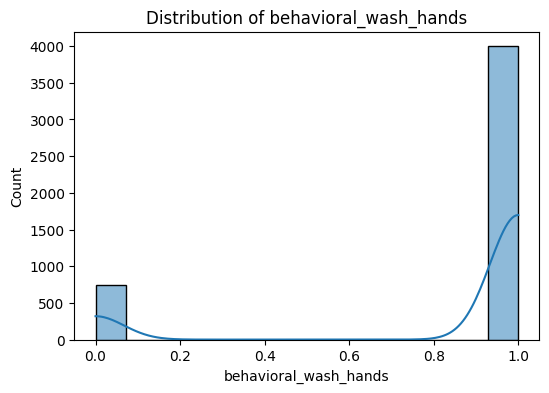

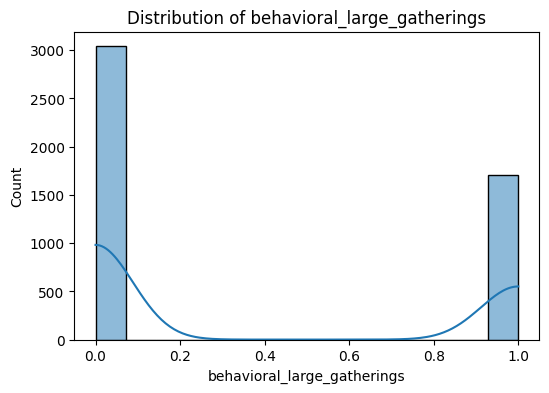

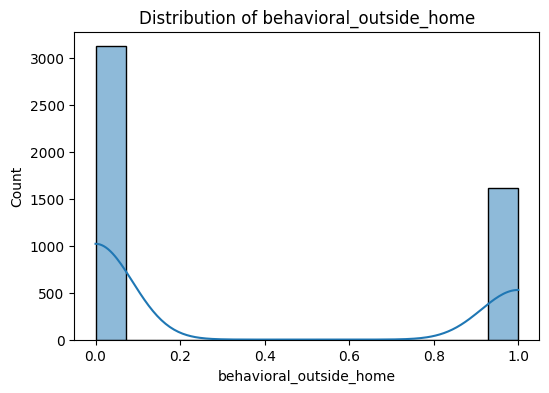

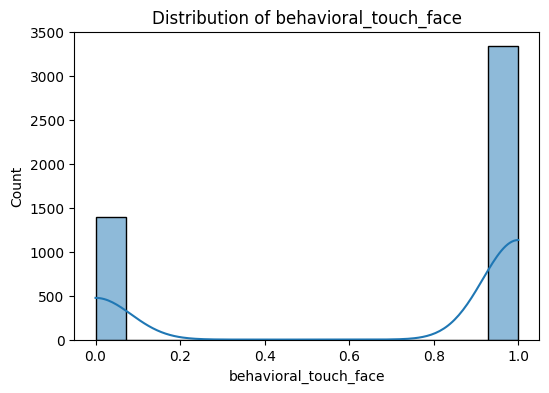

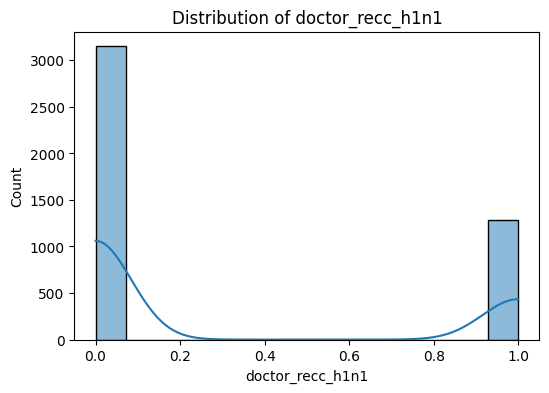

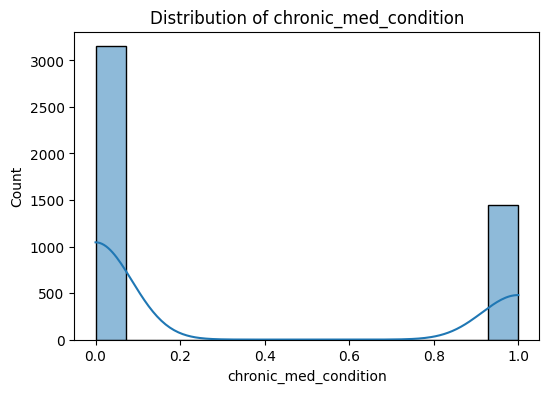

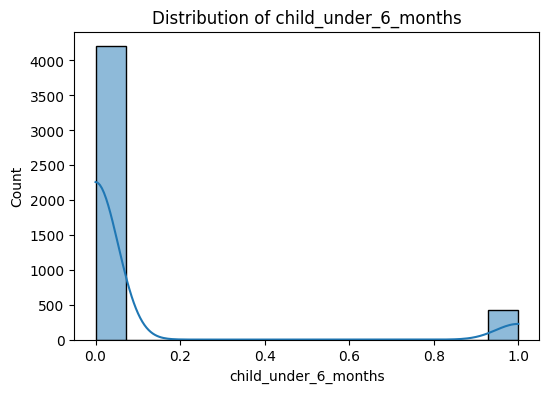

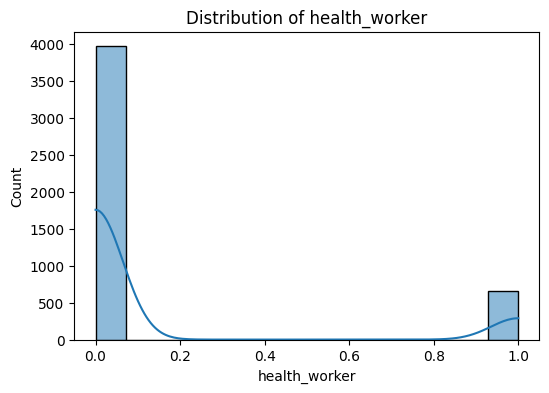

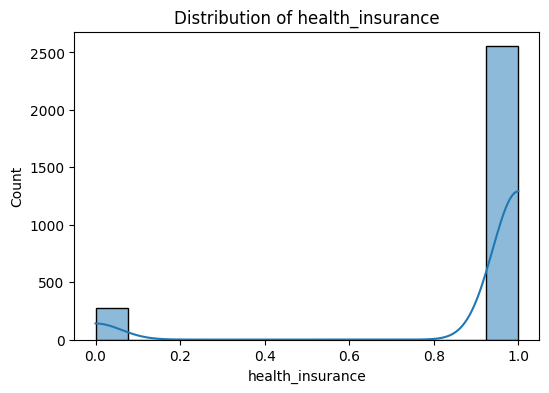

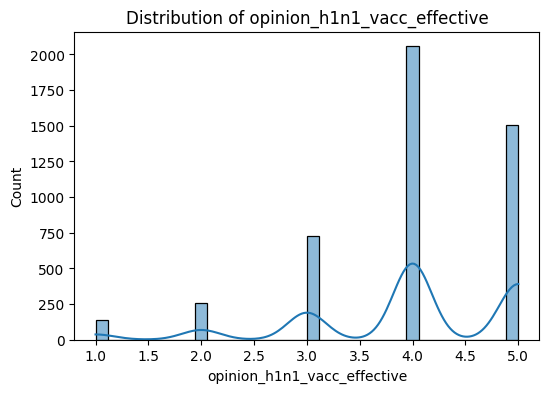

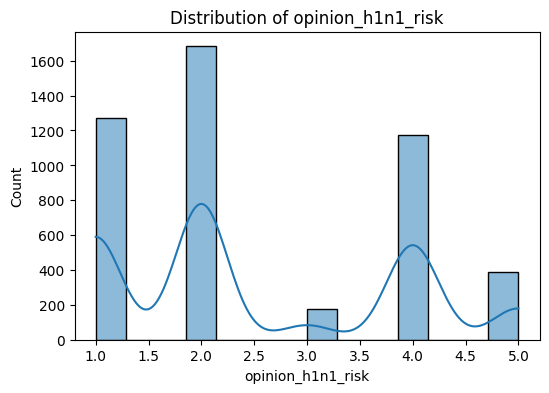

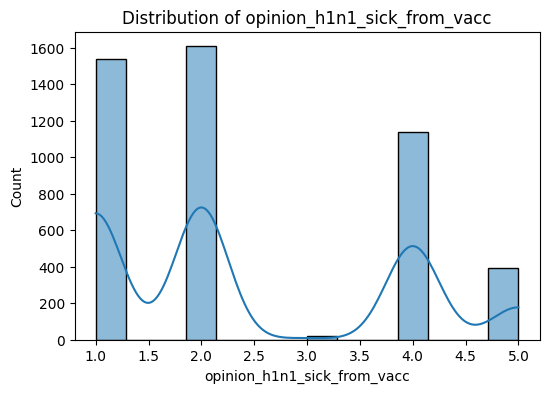

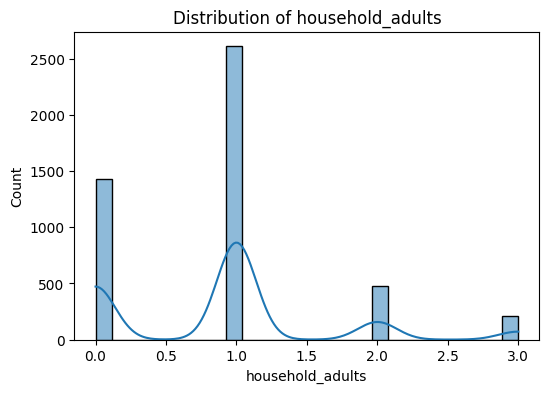

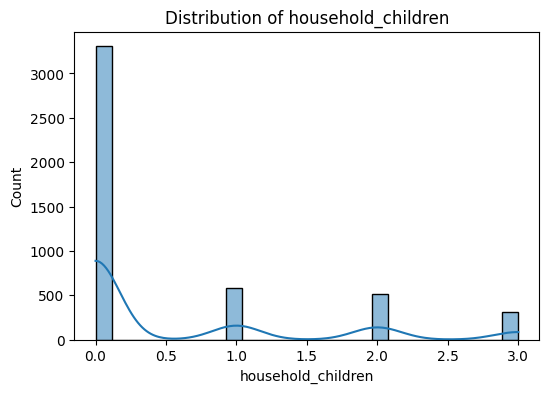

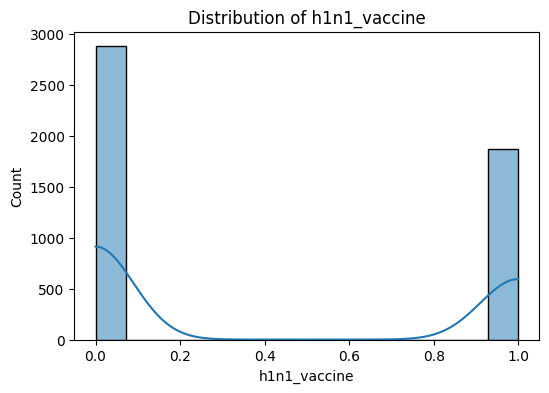

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = train.select_dtypes(include='number').columns

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(train[col], kde=True)

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.ylabel('Count')

    plt.show()

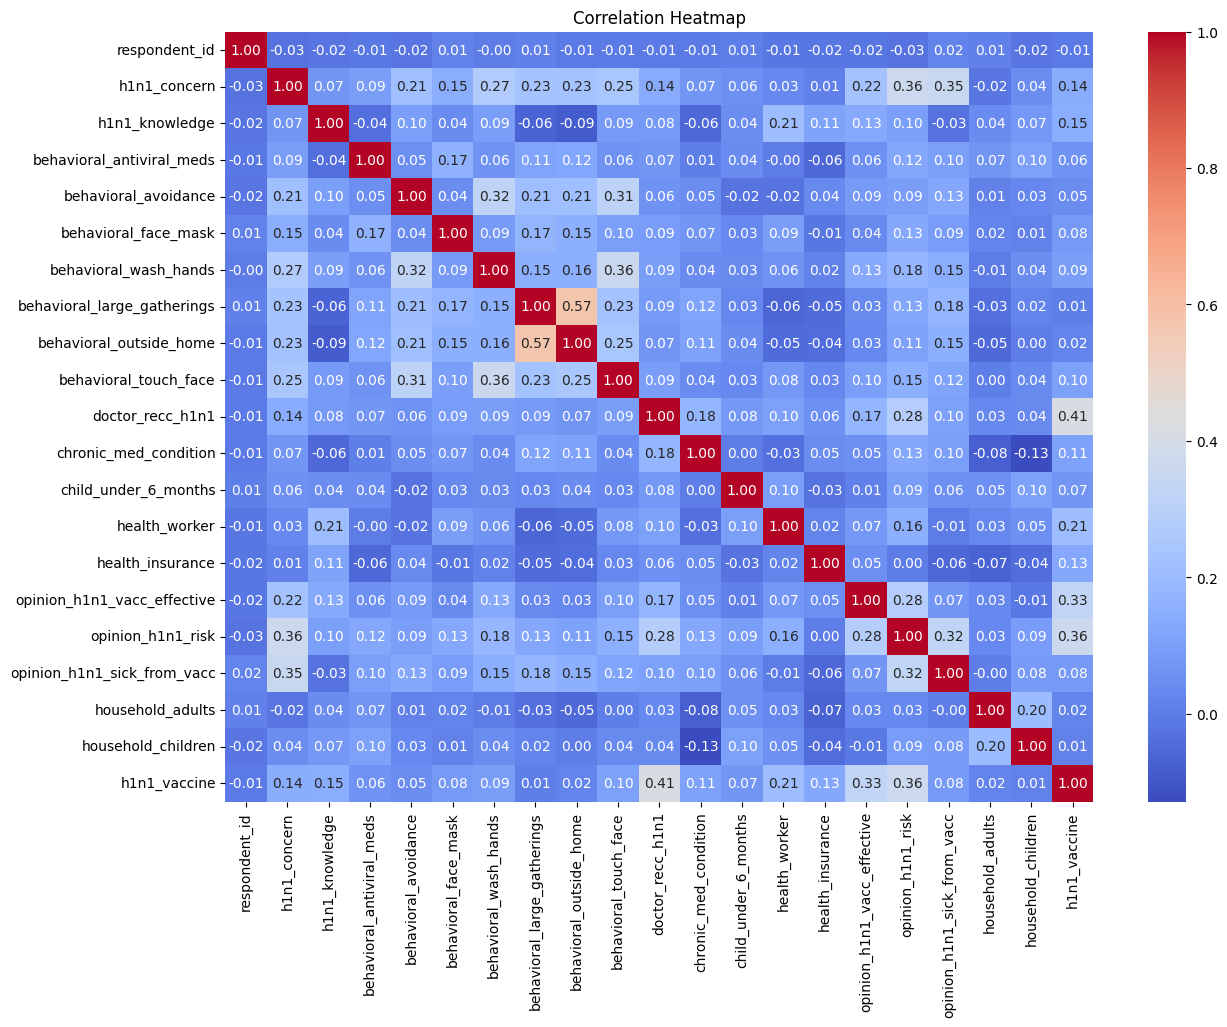

In [40]:
numeric_df = train.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [41]:
corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

strong_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

print("TOP 10 STRONGEST CORRELATIONS")
print(strong_corr.head(10))

TOP 10 STRONGEST CORRELATIONS
behavioral_large_gatherings  behavioral_outside_home        0.572640
doctor_recc_h1n1             h1n1_vaccine                   0.413874
h1n1_concern                 opinion_h1n1_risk              0.363881
opinion_h1n1_risk            h1n1_vaccine                   0.362183
behavioral_wash_hands        behavioral_touch_face          0.356210
h1n1_concern                 opinion_h1n1_sick_from_vacc    0.348217
opinion_h1n1_vacc_effective  h1n1_vaccine                   0.325057
opinion_h1n1_risk            opinion_h1n1_sick_from_vacc    0.324099
behavioral_avoidance         behavioral_wash_hands          0.318882
                             behavioral_touch_face          0.307726
dtype: float64


In [42]:
cat_cols = train.select_dtypes(include='object').columns

for col in cat_cols:

    print(f"{'='*30}")
    print(f"COLUMN: {col}")
    print(train[col].value_counts())

COLUMN: age_group
age_group
65+ Years        1225
55 - 64 Years    1065
45 - 54 Years     913
18 - 34 Years     894
35 - 44 Years     659
Name: count, dtype: int64
COLUMN: education
education
College Graduate    1858
Some College        1270
12 Years            1009
< 12 Years           395
Name: count, dtype: int64
COLUMN: race
race
White                3831
Black                 324
Other or Multiple     305
Hispanic              296
Name: count, dtype: int64
COLUMN: sex
sex
Female    2921
Male      1835
Name: count, dtype: int64
COLUMN: income_poverty
income_poverty
<= $75,000, Above Poverty    2250
> $75,000                    1342
Below Poverty                 452
Name: count, dtype: int64
COLUMN: marital_status
marital_status
Married        2535
Not Married    1995
Name: count, dtype: int64
COLUMN: rent_or_own
rent_or_own
Own     3466
Rent     975
Name: count, dtype: int64
COLUMN: employment_status
employment_status
Employed              2419
Not in Labor Force    1838
Unemployed

In [43]:

# -----------------------
# 1. MEDIAN IMPUTATION
# -----------------------
X = X.fillna(X.median())
test_processed = test.fillna(X.median())

# -----------------------
# 2. ONE-HOT ENCODING
# -----------------------
X = pd.get_dummies(X)
test_processed = pd.get_dummies(test_processed)

# Align train and test columns
X, test_processed = X.align(test_processed, join='left', axis=1, fill_value=0)

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score
from xgboost import XGBClassifier

Target = "h1n1_vaccine"

X = train.drop(Target, axis=1)
y = train[Target]

# -----------------------
# 1. IMPUTATION
# -----------------------
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Median imputation (NUMERIC)
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
test[num_cols] = test[num_cols].fillna(X[num_cols].median())

# Mode imputation (CATEGORICAL)
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])
    test[col] = test[col].fillna(X[col].mode()[0])

#  ONE-HOT ENCODING

X = pd.get_dummies(X, columns=cat_cols)
test_processed = pd.get_dummies(test, columns=cat_cols)

# Align train and test columns (ensures same features in both)
X, test_processed = X.align(test_processed, join='left', axis=1, fill_value=0)

# Clean column names for XGBoost (removes characters like [ or <)
X.columns = [col.replace("[", "_").replace("]", "_").replace("<", "_") for col in X.columns]
test_processed.columns = [col.replace("[", "_").replace("]", "_").replace("<", "_") for col in test_processed.columns]

# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Build XGBoost model
model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# Train model
model.fit(X_train, y_train)

# Make predictions
pred = model.predict(X_valid)

# Evaluation metrics
accuracy = accuracy_score(y_valid, pred)
recall = recall_score(y_valid, pred)
f1 = f1_score(y_valid, pred)

print("Accuracy", round(accuracy, 4))
print("Recall  ", round(recall, 4))
print("F1 Score", round(f1, 4))

# Train on full data and predict test data
model.fit(X, y)
test_predictions = model.predict(test_processed)

# Create submission file
submission = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "h1n1_vaccine": test_predictions
})

print("\nFirst 20 Predictions on Validation Set:")
results = pd.DataFrame({"Actual": y_valid.values, "Predicted": pred})
print(results.head(10))

submission.to_csv("submission.csv", index=False)
print(f"submission.csv created successfully.")

Accuracy 0.7616
Recall   0.6387
F1 Score 0.6825

First 20 Predictions on Validation Set:
   Actual  Predicted
0       0          1
1       1          0
2       1          1
3       0          0
4       0          0
5       0          0
6       1          1
7       0          0
8       1          1
9       1          1
submission.csv created successfully.
